In [1]:
import sys
sys.path.append('..')
from run.run_gspa import calculate_wavelet_dictionary
from utils import *

In [59]:
import numpy as np
import phate, scprep
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [ ]:
trajectory_data = np.load('../data/splatter_simulated_data.npz')
data_libnorm_sqrt = trajectory_data['data']
pseudotime = trajectory_data['pseudotime']
data_libnorm_sqrt= data_libnorm_sqrt[np.argsort(pseudotime)]
pseudotime = np.array(list(range(10000))) / 10000

print ('Compute PHATE...')
phate_op = phate.PHATE(random_state=0, use_pygsp=True, verbose=0, n_jobs=1)
data_phate = phate_op.fit_transform(data_libnorm_sqrt)

In [211]:
signal = StandardScaler().fit_transform(data_phate[:, 0].reshape(-1,1)).flatten()

<AxesSubplot:>

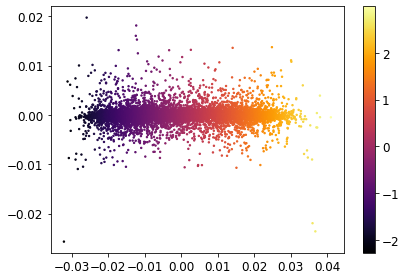

In [229]:
scprep.plot.scatter2d(data_phate, c=signal, filename='figures/designed_signal.png', dpi=200)

In [230]:
sinusoidal = np.sin(4*signal).flatten()

<AxesSubplot:>

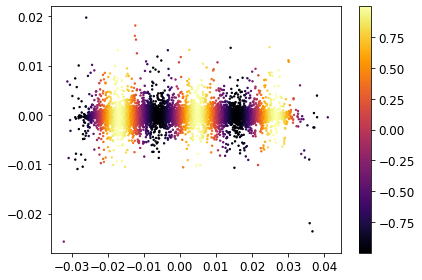

In [231]:
scprep.plot.scatter2d(data_phate, c=sinusoidal, filename='figures/designed_sinusoidal.png', dpi=200)

<AxesSubplot:>

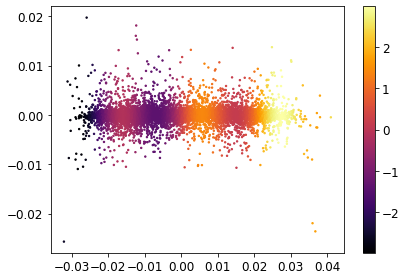

In [232]:
scprep.plot.scatter2d(data_phate, c=signal + sinusoidal)

In [216]:
np.random.seed(0)
noise = np.random.uniform(-1,1, size=signal.shape[0])

<AxesSubplot:>

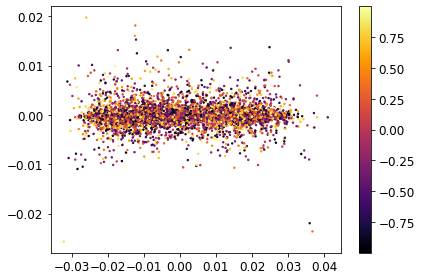

In [233]:
scprep.plot.scatter2d(data_phate, c=noise, filename='figures/designed_noise.png', dpi=200)

<AxesSubplot:>

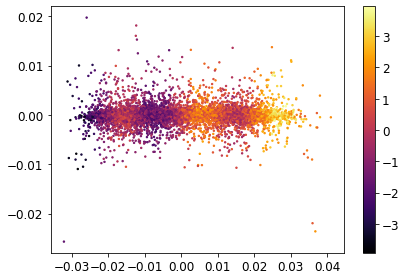

In [235]:
scprep.plot.scatter2d(data_phate, c=signal + sinusoidal + noise, filename='figures/designed_final_signal.png', dpi=200)

In [219]:
import magic

In [220]:
magic_op = magic.MAGIC(t=3)
magic_op.graph = phate_op.graph
data_magic = magic_op.transform((signal + sinusoidal + noise).reshape(-1,1))

Calculating imputation...


/home/aarthivenkat/.local/lib/python3.8/site-packages/magic/magic.py:541: UserWarning: Running MAGIC.transform on different data to that which was used for MAGIC.fit may not produce sensible output, unless it comes from the same manifold.
  warnings.warn(


<AxesSubplot:>

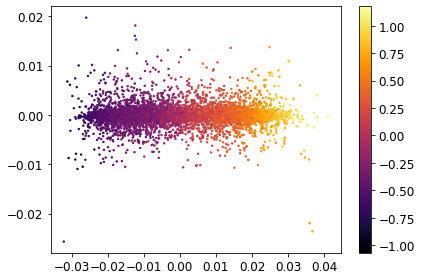

In [237]:
scprep.plot.scatter2d(data_phate, c=data_magic, filename='figures/magic_on_signal.png', dpi=200)

In [175]:
cell_dictionary, wavelet_sizes = calculate_wavelet_dictionary(phate_op.graph, use_reduced=False, power=2, J=5)

Maximum scale: 5
Calculating Wavelets J = 5


100%|██████████| 3/3 [00:20<00:00,  6.68s/it]


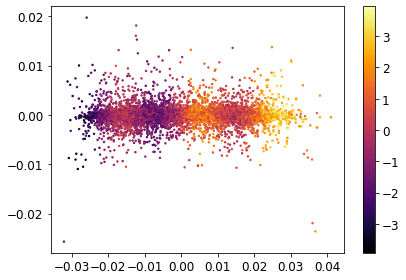

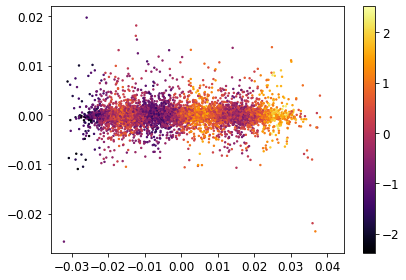

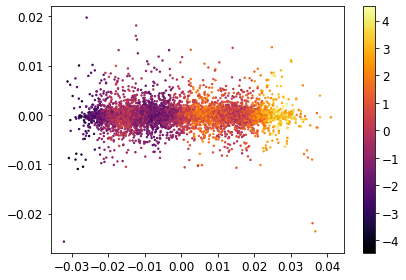

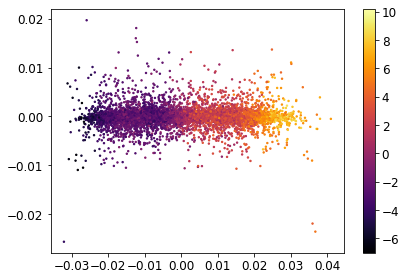

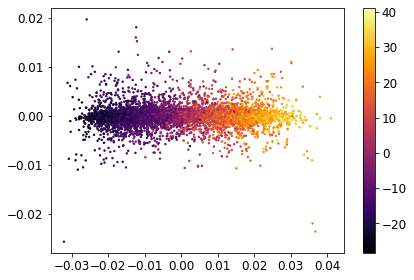

In [238]:
for i in range(5):
    projected = project((signal + sinusoidal + noise).reshape(-1,1).T, cell_dictionary[:, i*10000:(i+1)*10000])
    scprep.plot.scatter2d(data_phate, c=projected, filename=f'figures/projected_on_wavelet_{i+1}_signal.png', dpi=200)